In [2]:

import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
# sys.path = original_sys_path

In [3]:
max_ql = 25
max_ol = 50
system = fluxonium_oscillator_system(
    EJ = 2.5,
    EC = 0.65,
    EL = 0.12,
    Er = 7.05877808,
    g_strength = 0.23,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.001,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2',
    drive_transition = ((3,0),(3,1))
    )

# t_stop = 668
tot_time =418
tlist = np.linspace(0, tot_time, tot_time)

results = system.run_mesolve_on_driving_osc(
    initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(i, 0)])) for i in range(4)],
    tlist = tlist,
    osc_decay = False,
    amp = 0.003,
    # t_stop = t_stop
)


import pickle
with open('../pickles/sesolve_12_large_dim_three_outcome.pkl', 'wb') as file:
    pickle.dump(results, file)


 [          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 0.00s / Remaining 00:00:00:00[          0%           ] Elapsed 1.63s / Remaining 00:00:00:00[          0%           ] Elapsed 1.63s / Remaining 00:00:00:00[          0%           ] Elapsed 3.31s / Remaining 00:00:00:00[          0%           ] Elapsed 3.49s / Remaining 00:00:00:00[          0%           ] Elapsed 3.58s / Remaining 00:00:00:00[          1%           ] Elapsed 6.18s / Remaining 00:00:10:11[          1%           ] Elapsed 8.51s / Remaining 00:00:14:02[          0%           ] Elapsed 11.44s / Remaining 00:00:00:00[          0%           ] Elapsed 12.29s / Remaining 00:00:00:00[          1%           ] Elapsed 12.50s / Remaining 00:00:20:37[          0%           ] Elapsed 15.27s / Remaining 00:00:00:00[          1%           ] Elapsed 15.42s / Remaini

In [3]:
with open('../pickles/sesolve_12_large_dim_three_outcome.pkl', 'rb') as file:
    results = pickle.load(file)

In [5]:
lists = []
for ql in [0,1,2,3]:
    pop_list = []
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        pop_sum = 0
        for q in range(system.qbt.truncated_dim):
            if q != ql:
                for o in range(system.osc.truncated_dim):
                    product_state = (q, o)
                    dressed_state = system.product_to_dressed[product_state]
                    basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                    expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                    pop_sum += expectation_value

        pop_list.append(pop_sum)
    # print(pop_list)
    lists.append(pop_list)
with open('../pickles/sesolve_12_large_dim_leakage_list_three_outcome.pkl', 'wb') as file:
    pickle.dump(lists, file)

t loop: 100%|██████████| 418/418 [01:12<00:00,  5.79it/s]


Text(0.5, 0, 't (ns)')

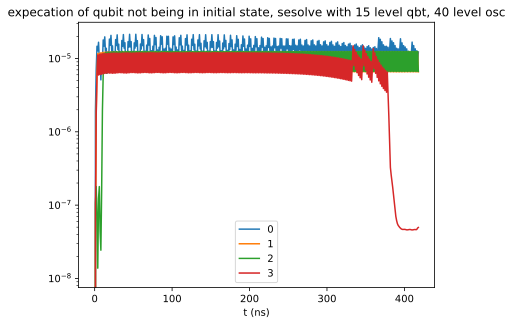

In [6]:
with open('../pickles/sesolve_12_large_dim_leakage_list_three_outcome.pkl', 'rb') as file:
    lists = pickle.load(file)
    
for ql,pop_list in enumerate(lists): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.yscale('log')
plt.legend()
plt.title('expecation of qubit not being in initial state, sesolve with 15 level qbt, 40 level osc')
plt.xlabel('t (ns)')

In [7]:
lists = []
for ql in [0,1,2,3]:
    pops_list = [[] for _ in range(system.qbt.truncated_dim)]
    for t_idx in tqdm(range(len(tlist)), desc = "t loop"):
        dm = results[ql].states[t_idx]
        for q in range(system.qbt.truncated_dim):
            sum_at_this_t_for_this_q = 0
            for o in range(system.osc.truncated_dim):
                product_state = (q, o)
                dressed_state = system.product_to_dressed[product_state]
                basis_state = qutip.basis(dm.dims[0][0], dressed_state)
                expectation_value = qutip.expect(basis_state * basis_state.dag(), dm)
                sum_at_this_t_for_this_q += expectation_value
            pops_list[q].append(sum_at_this_t_for_this_q)
    lists.append(pops_list)

with open('../pickles/sesolve_12_large_dim_qubit_pop_list_three_outcome.pkl', 'wb') as file:
    pickle.dump(lists, file)

t loop: 100%|██████████| 418/418 [01:12<00:00,  5.79it/s]


In [ ]:
with open('../pickles/sesolve_12_large_dim_qubit_pop_list_three_outcome.pkl', 'rb') as file:
    lists = pickle.load(file)

Text(0.5, 0, 't (ns)')

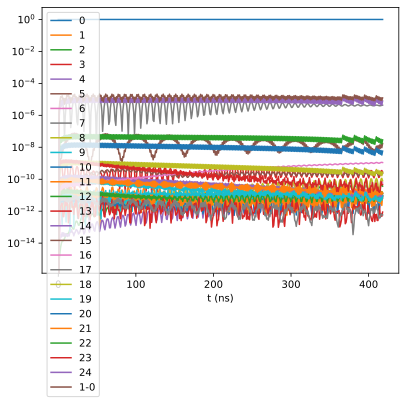

In [10]:
qls = [7,4,24,2,12,22,10,20]
qls = list(range(25))
for ql,pop_list in zip(qls,[lists[0][j] for j in qls]): 
# for ql,pop_list in enumerate(lists[0][:]): 
    plt.plot(tlist,pop_list,label = f"{ql}")
plt.plot(tlist,1-np.array(lists[0][0]),label = f"1-{0}")
plt.yscale('log')
plt.legend()
plt.xlabel('t (ns)')

In [14]:
interactive_heatmap(results[3], system.product_to_dressed, system.qbt.truncated_dim, system.osc.truncated_dim)

interactive(children=(IntSlider(value=0, continuous_update=False, description='Time Index:', max=417), Output(…

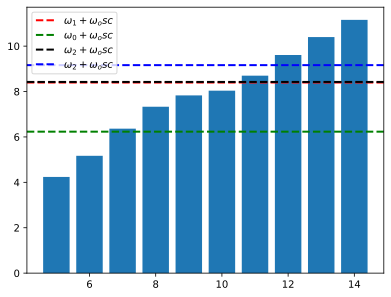

In [15]:
evals = system.qbt.eigenvals(15)


import matplotlib.pyplot as plt

x_positions = range(len(evals))
plt.bar(x_positions[5:], evals[5:])
plt.axhline(y=evals[1] + system.w_d, color='r', linestyle='--', linewidth=2,label=r'$\omega_1 + \omega_osc$')
plt.axhline(y=evals[0] + system.w_d, color='g', linestyle='--', linewidth=2,label=r'$\omega_0 + \omega_osc$')
plt.axhline(y=evals[2] + system.w_d, color='black', linestyle='--', linewidth=2,label=r'$\omega_2 + \omega_osc$')
plt.axhline(y=evals[3] + system.w_d, color='blue', linestyle='--', linewidth=2,label=r'$\omega_2 + \omega_osc$')

plt.legend()

In [16]:
table = np.abs(system.qbt.matrixelement_table(operator='n_operator',evals_count = 15))
# table[0,7], [
#     [table[1,10],table[1,11]],
#     [table[2,10],table[2,11]]
# ]
print(f"detunning to 0-7 {abs(evals[7]-evals[0]-system.w_d)}, matrix_ele: {table[0,7]}")
print(f"detunning to 1-10 {abs(evals[10]-evals[1]-system.w_d)}, matrix_ele: {table[1,10]}")
print(f"detunning to 2-11 {abs(evals[11]-evals[2]-system.w_d)}, matrix_ele: {table[2,11]}")
print(f"detunning to 3-12 {abs(evals[12]-evals[3]-system.w_d)}, matrix_ele: {table[3,12]}")

detunning to 0-7 0.13082745855483502, matrix_ele: 0.0640758786723135
detunning to 1-10 0.3571901097132235, matrix_ele: 0.021129311885050163
detunning to 2-11 0.2755917661708631, matrix_ele: 0.04247047195544418
detunning to 3-12 0.44492019802944593, matrix_ele: 0.08556729367214488
